# Support Vector Machines (SVM) for Fake Review Detection

## 1. Introduction
Support Vector Machines (SVM) are particularly effective for high-dimensional data like TF-IDF vectors. In this notebook, we use a **Linear SVM** (`LinearSVC`) to classify reviews.

---


## 2. Environment Setup & Data Loading

We start by importing necessary libraries, setting a seed for reproducibility, and defining paths for data and model persistence. We load the precomputed TF-IDF features and split them into training (80%) and testing (20%) sets.


In [1]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
RANDOM_STATE = 42
DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIGURES_DIR = "../figures"

# Create directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set theme for plots
sns.set_theme(style="whitegrid")

print("Loading TF-IDF features and labels...")
X = joblib.load(os.path.join(DATA_DIR, "X_tfidf.pkl"))
y = joblib.load(os.path.join(DATA_DIR, "y.pkl"))
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Loading TF-IDF features and labels...
Features shape: (40432, 15000)
Labels shape: (40432,)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Data split successfully:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Data split successfully:
Training samples: 32345
Testing samples: 8087


## 3. Hyperparameter Tuning

We perform a grid search over the regularization parameter `C` to find the optimal trade-off between margin width and classification error.


In [3]:
param_grid = {
    'C': np.logspace(-2, 1, 10)
}

print("Starting Hyperparameter Tuning...")
grid_search = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE, max_iter=2000, dual=False),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': np.float64(0.46415888336127775)}
Best CV Score: 0.9064


## 4. Model Evaluation

We evaluate the optimized model on the unseen test set using accuracy and a detailed classification report.


In [4]:
y_pred = best_model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Real (OR)", "Fake (CG)"]))


Test Accuracy: 0.9126

Classification Report:

              precision    recall  f1-score   support

   Real (OR)       0.91      0.91      0.91      4044
   Fake (CG)       0.91      0.91      0.91      4043

    accuracy                           0.91      8087
   macro avg       0.91      0.91      0.91      8087
weighted avg       0.91      0.91      0.91      8087



## 5. Visualizing Results

We visualize the model performance using a Confusion Matrix.


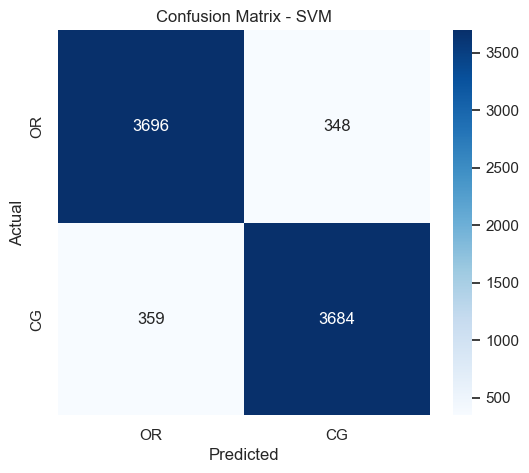

In [5]:
# 5.1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.savefig(os.path.join(FIGURES_DIR, "svm_confusion_matrix.png"))
plt.show()


## 6. Model Persistence

Finally, we save the trained model for future inference.


In [6]:
model_path = os.path.join(MODELS_DIR, "svm_model.pkl")
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")


Model saved to: ../models\svm_model.pkl
